# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Srilaya30/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question

Can search-performance and content signals be used to rank content pages that show signs associated with decline, so that a content team can prioritize pages for human review?

Decision Supported

The analysis is intended to help a content team decide which pages may deserve attention first. The model produces a ranking and reason codes that can be used as decision support. It does not decide automatically whether a page should be changed, refreshed, deleted, or redirected.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data Used

This project uses the FlyRank ML Internship search dataset available to the internship cohort. The analysis uses anonymized content-page and search-performance records.

The dataset contains page-level search and engagement signals such as impressions, clicks, sessions, content age, CTR, average position, and related performance measures.

Exclusions

I excluded trend_direction and trend_pct from the model features because they are directly related to the target definition. Including them would give the model information about the outcome it is supposed to predict.

Client-identifying information is used only for grouped validation and is not included in the public recommendation output.

No client names, domains, private queries, credentials, or raw private exports are included in the public-facing paper.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

repo_root = Path("/content/flyrank-ml-internship")

if not repo_root.exists():
    !git clone -q https://github.com/Srilaya30/flyrank-ml-internship.git

data_path = (
    repo_root
    / "data"
    / "raw"
    / "content_refresh_anonymized.csv"
)

print("Dataset exists:", data_path.exists())

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

Dataset exists: True
Dataset shape: (30000, 44)
Number of columns: 44


Target Definition

I define a declining page as a page whose trend direction is down. This creates a binary target called is_declining_label. A value of 1 represents the declining class and 0 represents the other class.

In [2]:
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget proportions:")
print(df["is_declining_label"].value_counts(normalize=True))

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
is_declining_label
1    0.542067
0    0.457933
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Features

The model uses search, engagement, content-age, and page-performance signals available before the prediction. The final feature set contains 29 variables.

I do not use trend_direction, trend_pct, or the target label as model features.

In [3]:
feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[feature_cols].copy()
y = df["is_declining_label"].copy()

print("Features:", len(feature_cols))
print("X shape:", X.shape)

Features: 29
X shape: (30000, 29)


Validation Design

I use a client-grouped train/test split rather than randomly splitting individual pages. This keeps pages belonging to the same client together. The test set therefore contains clients that were not used for training.

This provides a more conservative estimate of how the model may behave when applied to unseen clients.

In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=df["client_id"]
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(
    df.iloc[train_idx]["client_id"]
)

test_clients = set(
    df.iloc[test_idx]["client_id"]
)

print("Training rows:", len(train_idx))
print("Testing rows:", len(test_idx))
print("Client overlap:",
      len(train_clients & test_clients))

Training rows: 23837
Testing rows: 6163
Client overlap: 0


Model

I use a Random Forest classifier. It combines multiple decision trees and can capture nonlinear relationships between the available search-performance signals and the declining label.

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


In [6]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return np.mean(np.asarray(y_true)[order])

model_p20 = precision_at_k(
    y_test.to_numpy(),
    y_prob,
    20
)

print(
    "Random Forest Precision@20:",
    round(model_p20, 4)
)

Random Forest Precision@20: 1.0


Baseline

I compare the Random Forest with the Week-4 heuristic baseline. The baseline combines page staleness and CTR opportunity into a simple ranking score. Both approaches are evaluated on the same client-grouped test set using Precision@20.

In [7]:
baseline_test = df.iloc[test_idx].copy()

baseline_test["staleness_score"] = (
    baseline_test["days_since_last_update"]
    .rank(method="average", pct=True)
)

baseline_test["ctr_opportunity_score"] = (
    1
    - baseline_test["ctr"]
    .rank(method="average", pct=True)
)

baseline_test["baseline_score"] = (
    0.60 * baseline_test["staleness_score"]
    + 0.40 * baseline_test["ctr_opportunity_score"]
)

baseline_p20 = precision_at_k(
    baseline_test["is_declining_label"].to_numpy(),
    baseline_test["baseline_score"].to_numpy(),
    20
)

print(
    "Baseline Precision@20:",
    round(baseline_p20, 4)
)

Baseline Precision@20: 0.45


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

On the client-grouped test set, the Random Forest measured a Precision@20 of 1.00, compared with 0.45 for the Week-4 baseline. This is an observed result on this test set and should be interpreted as directional evidence rather than a guarantee of future performance.

In [8]:
comparison = pd.DataFrame({
    "Approach": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Precision@20": [
        baseline_p20,
        model_p20
    ]
})

comparison

,Approach,Precision@20
0,Week-4 baseline,0.45
1,Random Forest,1.00


In [9]:
target_related_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

leakage_found = [
    col
    for col in feature_cols
    if col in target_related_columns
]

print("Potential leakage columns:", leakage_found)

if len(leakage_found) == 0:
    print("PASS: No direct target-related columns detected.")
else:
    print("REVIEW REQUIRED")

Potential leakage columns: []
PASS: No direct target-related columns detected.


## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations. The model was evaluated on one dataset using a client-grouped test split, so its measured performance may not generalize to other datasets, clients, or future periods.

Precision@20 measures the quality of the highest-ranked pages in this test set; it does not prove that the model will always rank useful pages first.

Feature importance indicates which signals the model relied on, but it does not establish causation.

The model identifies pages associated with the declining label. It does not prove why a page declined or guarantee that refreshing a page will improve its performance.

Therefore, the output should be used as decision support for human review, not as an automatic content-management system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [13]:
action_queue = df.iloc[test_idx].copy()

action_queue["decline_score"] = y_prob

def get_reason_code(row):
    reasons = []

    if row["days_since_last_update"] > df[
        "days_since_last_update"
    ].median():
        reasons.append("STALENESS")

    if row["content_age_days"] > df[
        "content_age_days"
    ].median():
        reasons.append("OLDER_CONTENT")

    if row["impressions_last_30d"] < row[
        "impressions_prev_30d"
    ]:
        reasons.append("RECENT_IMPRESSION_DECLINE")

    if row["avg_position"] > df[
        "avg_position"
    ].median():
        reasons.append("WEAKER_POSITION")

    if row["ctr"] < df["ctr"].median():
        reasons.append("LOWER_CTR")

    if not reasons:
        reasons.append("MODEL_SIGNAL")

    return ", ".join(reasons[:3])

action_queue["reason_code"] = action_queue.apply(
    get_reason_code,
    axis=1
)

action_queue["priority_rank"] = (
    action_queue["decline_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

ranked_actions = action_queue.sort_values(
    "decline_score",
    ascending=False
)[
    [
        "priority_rank",
        "content_id",
        "decline_score",
        "reason_code"
    ]
]

ranked_actions.head(20)

,priority_rank,content_id,decline_score,reason_code
29681,3,content_9e8671965fff,0.995,RECENT_IMPRESSION_DECLINE
20543,2,content_d028d97a0f72,0.995,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
19110,1,content_eb58f272b967,0.995,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
14044,5,content_ed65b2e130c6,0.985,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
14937,6,content_06b02c9b01a1,0.985,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
3329,4,content_eb3b2c3bbc34,0.985,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
18822,10,content_b23d650634c6,0.980,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
13454,9,content_0b50482209cd,0.980,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"
7502,7,content_630f434b6951,0.980,"OLDER_CONTENT, RECENT_IMPRESSION_DECLINE, LOWE..."
11751,8,content_37bb865c7f2f,0.980,"RECENT_IMPRESSION_DECLINE, LOWER_CTR"


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [14]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance.head(10)

,0
impressions_prev_30d,0.204260
impressions_last_30d,0.169643
impressions_90d,0.079278
avg_position,0.057535
days_with_impressions,0.050561
content_age_days,0.048926
sessions_last_30d,0.028343
word_count,0.027802
char_count,0.027741
ctr,0.025489


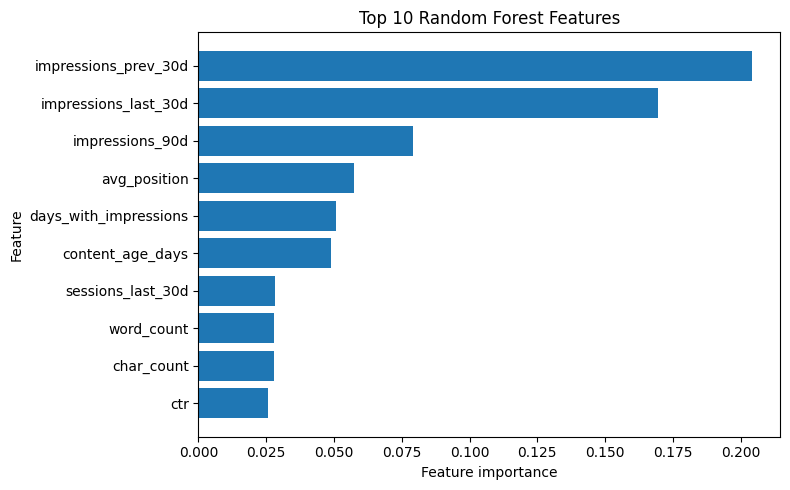

In [15]:
import matplotlib.pyplot as plt

top_features = (
    feature_importance
    .head(10)
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features.index,
    top_features.values
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()

plt.show()

In [16]:
output_dir = (
    repo_root
    / "work"
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

comparison.to_csv(
    output_dir / "capstone_model_comparison.csv",
    index=False
)

ranked_actions.to_csv(
    output_dir / "capstone_ranked_actions.csv",
    index=False
)

feature_importance.to_csv(
    output_dir / "capstone_feature_importance.csv",
    header=["importance"]
)

print("Capstone artifacts exported.")

Capstone artifacts exported.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [17]:
print("CAPSTONE FINAL CHECK")
print("--------------------")
print("Features:", len(feature_cols))
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Client overlap:",
      len(train_clients & test_clients))
print("Model Precision@20:",
      round(model_p20, 4))
print("Baseline Precision@20:",
      round(baseline_p20, 4))
print("Leakage columns:",
      leakage_found)
print("Ranked recommendations:",
      len(ranked_actions))
print(
    "Artifacts directory exists:",
    output_dir.exists()
)

CAPSTONE FINAL CHECK
--------------------
Features: 29
Train rows: 23837
Test rows: 6163
Client overlap: 0
Model Precision@20: 1.0
Baseline Precision@20: 0.45
Leakage columns: []
Ranked recommendations: 6163
Artifacts directory exists: True
